<a href="https://colab.research.google.com/github/mafudsetiono/Food-Delivery-Time-Prediction/blob/main/Delivery_Time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚚 Prediksi Waktu Pengiriman Makanan

## 🎯 Tujuan Proyek

Tujuan dari proyek ini adalah membangun model machine learning yang mampu memprediksi waktu pengiriman makanan secara akurat berdasarkan berbagai faktor operasional dan kondisi lingkungan, seperti jarak pengiriman, kondisi cuaca, tingkat kemacetan, waktu dalam sehari, jenis kendaraan, waktu persiapan makanan, serta pengalaman kurir.

Melalui pemanfaatan data tersebut, proyek ini bertujuan untuk:

* Mengidentifikasi faktor-faktor utama yang memengaruhi waktu pengiriman
* Membangun dan membandingkan beberapa model regresi untuk mendapatkan model terbaik
* Meningkatkan akurasi estimasi waktu pengiriman guna mendukung efisiensi operasional dan meningkatkan kepuasan pelanggan

Project ini merepresentasikan studi kasus nyata dalam industri layanan pengantaran makanan, di mana estimasi waktu pengiriman yang akurat sangat penting untuk menjaga kualitas layanan dan pengalaman pengguna.


#Load Dataset

In [1]:
# Import library utama
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

In [2]:
# Load dataset
df = pd.read_csv('Food_Delivery_Times.csv')

# Lihat 5 data teratas
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [3]:
# Informasi dataset
df.info()

# Statistik deskriptif
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


## Key Insights from Descriptive Statistics

- Rata-rata waktu pengiriman berada di sekitar 56 menit dengan variasi yang cukup besar, menunjukkan adanya faktor eksternal yang mempengaruhi keterlambatan
- Jarak pengiriman memiliki distribusi yang cukup merata dan kemungkinan menjadi faktor utama dalam menentukan waktu pengiriman
- Waktu persiapan makanan relatif stabil dan tidak menunjukkan variasi ekstrem
- Pengalaman kurir bervariasi dari pemula hingga berpengalaman, yang berpotensi mempengaruhi efisiensi pengiriman
- Ditemukan nilai maksimum yang cukup tinggi pada delivery time, yang mengindikasikan adanya kondisi ekstrem seperti kemacetan tinggi atau cuaca buruk

#Data Cleaning

In [4]:
# Cek data duplikat
df.duplicated().sum()

np.int64(0)

In [5]:
# Rapikan nama kolom
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
# Cek missing value
df.isnull().sum()

,0
order_id,0
distance_km,0
weather,30
traffic_level,30
time_of_day,30
vehicle_type,0
preparation_time_min,0
courier_experience_yrs,30
delivery_time_min,0


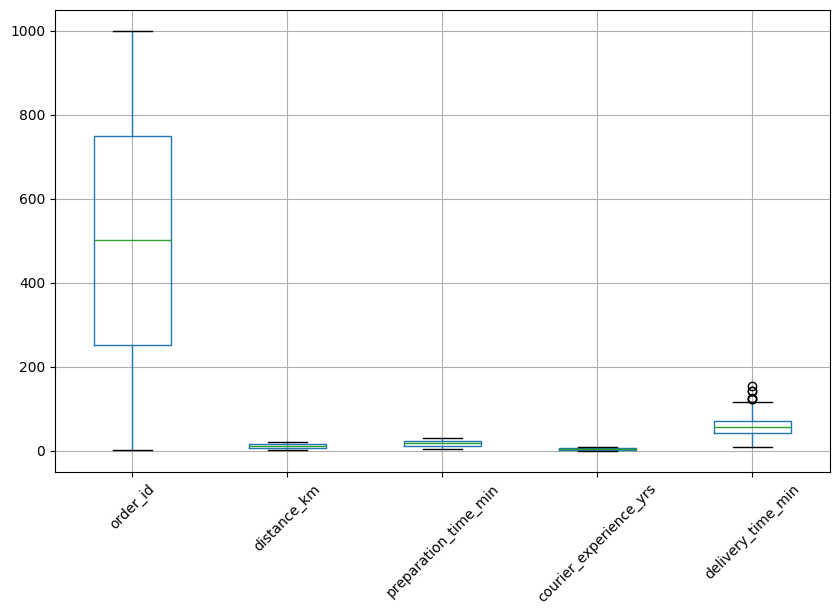

In [7]:
# Boxplot semua fitur numerik
df.boxplot(figsize=(10,6))
plt.xticks(rotation=45)
plt.show()

**Insight**

Outlier pada delivery time justru penting karena merepresentasikan kondisi ekstrem di lapangan seperti kemacetan tinggi atau cuaca buruk, sehingga tetap dipertahankan agar model dapat belajar dari kondisi tersebut.

In [8]:
# Handling missing value Categorical
cat_cols = ['weather', 'traffic_level', 'time_of_day']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [9]:
# Handling missing value Numeric
df['courier_experience_yrs'].fillna(df['courier_experience_yrs'].median(), inplace=True)

## Insight Data Clean

- Dataset memiliki missing values sebesar 3% pada beberapa kolom kategorikal dan numerik
- Missing values ditangani dengan:
  - Mode untuk fitur kategorikal
  - Median untuk fitur numerik
- Tidak ditemukan data duplikat
- Outlier ditemukan pada beberapa fitur seperti delivery time, namun tidak dihapus karena masih masuk akal dalam konteks dunia nyata (misalnya keterlambatan akibat kemacetan atau cuaca buruk)

#EDA

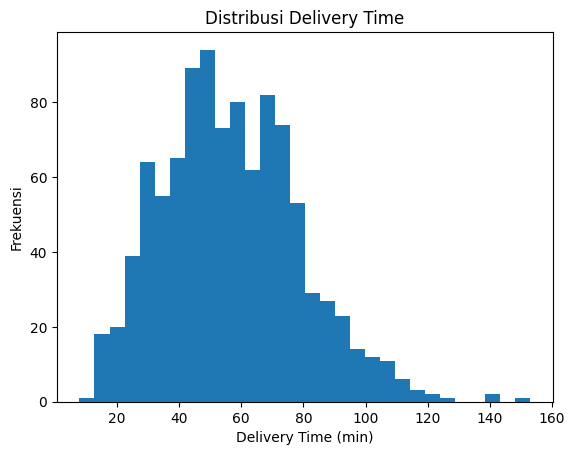

In [10]:
# Distribusi Delivery Time
plt.hist(df['delivery_time_min'], bins=30)
plt.title('Distribusi Delivery Time')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Frekuensi')
plt.show()

**Insight**

Distribusi waktu pengiriman menunjukkan pola yang mendekati normal dengan sedikit skew ke kanan. Sebagian besar pengiriman berada pada rentang 40–70 menit, dengan rata-rata sekitar 55–60 menit. Terdapat beberapa nilai ekstrem di atas 100 menit yang mengindikasikan adanya kondisi keterlambatan seperti kemacetan atau cuaca buruk.

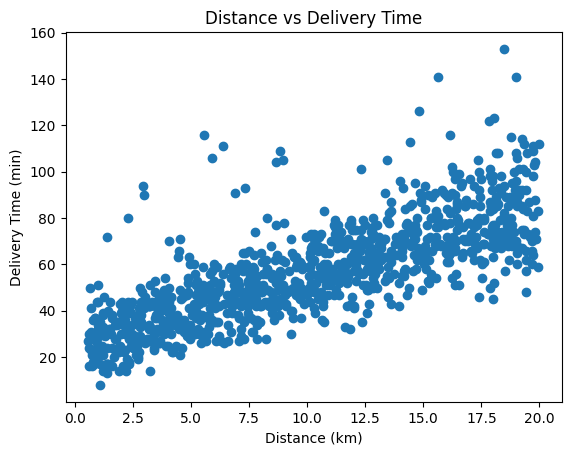

In [11]:
# Distance VS Delivery Time
plt.scatter(df['distance_km'], df['delivery_time_min'])
plt.title('Distance vs Delivery Time')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (min)')
plt.show()

**Insight**

Terdapat hubungan positif yang jelas antara jarak dan waktu pengiriman. Semakin jauh jarak pengiriman, semakin lama waktu yang dibutuhkan. Pola ini menunjukkan bahwa distance merupakan faktor utama yang mempengaruhi delivery time.

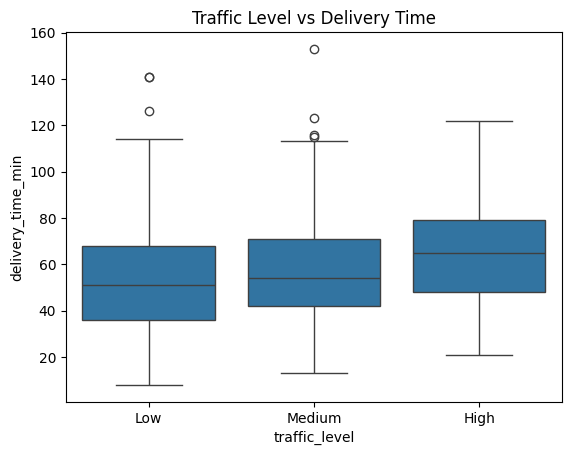

In [12]:
# Traffic Level vs Delivery Time
import seaborn as sns

sns.boxplot(x='traffic_level', y='delivery_time_min', data=df)
plt.title('Traffic Level vs Delivery Time')
plt.show()

**Insight**

Waktu pengiriman meningkat seiring dengan tingkat kemacetan. Kondisi traffic tinggi memiliki median delivery time yang lebih besar dibandingkan traffic rendah, menunjukkan bahwa kemacetan memberikan dampak signifikan terhadap keterlambatan pengiriman.

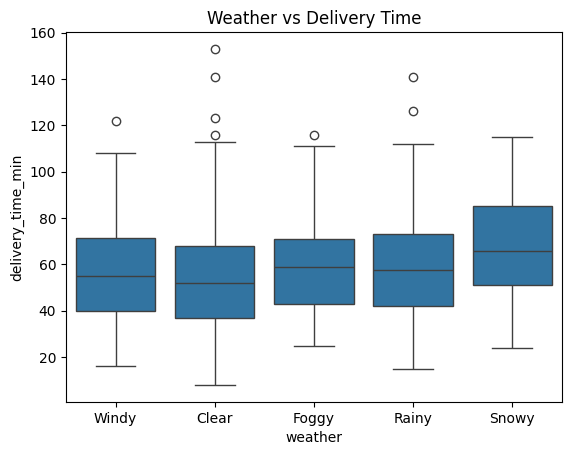

In [13]:
# Weather vs Delivery Time
sns.boxplot(x='weather', y='delivery_time_min', data=df)
plt.title('Weather vs Delivery Time')
plt.show()

**Insight**

Kondisi cuaca mempengaruhi waktu pengiriman, di mana cuaca ekstrem seperti snowy dan rainy cenderung memiliki median delivery time yang lebih tinggi dibandingkan kondisi normal seperti clear. Hal ini menunjukkan bahwa kondisi cuaca buruk dapat memperlambat proses pengiriman.

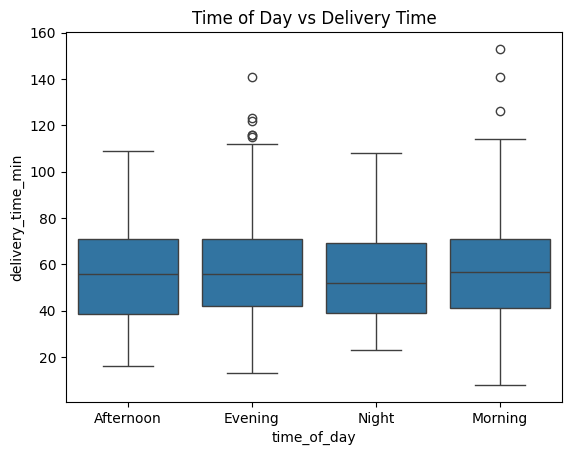

In [14]:
# Time of day vs Delivery Time
sns.boxplot(x='time_of_day', y='delivery_time_min', data=df)
plt.title('Time of Day vs Delivery Time')
plt.show()

**Insight**

Waktu pengiriman relatif bervariasi berdasarkan waktu dalam sehari. Morning dan evening cenderung memiliki waktu pengiriman yang lebih tinggi dibandingkan night, yang kemungkinan disebabkan oleh peningkatan aktivitas dan kepadatan lalu lintas pada jam sibuk.

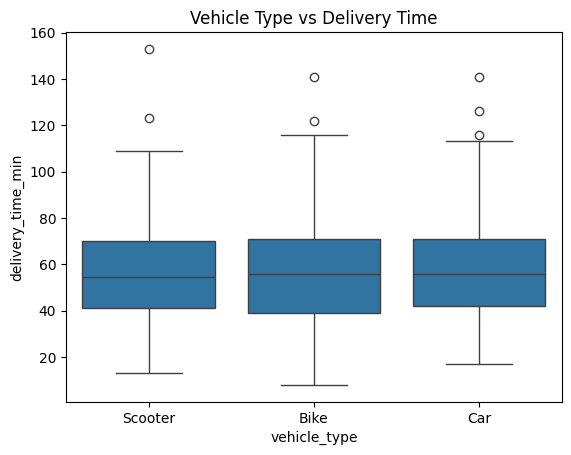

In [15]:
# Vehicle Type vs Delivery Time
sns.boxplot(x='vehicle_type', y='delivery_time_min', data=df)
plt.title('Vehicle Type vs Delivery Time')
plt.show()

**Insight**

Jenis kendaraan menunjukkan perbedaan yang tidak terlalu signifikan terhadap waktu pengiriman, meskipun kendaraan seperti car cenderung memiliki waktu yang sedikit lebih lama dibandingkan scooter dan bike. Hal ini dapat disebabkan oleh keterbatasan mobilitas kendaraan yang lebih besar di area padat.

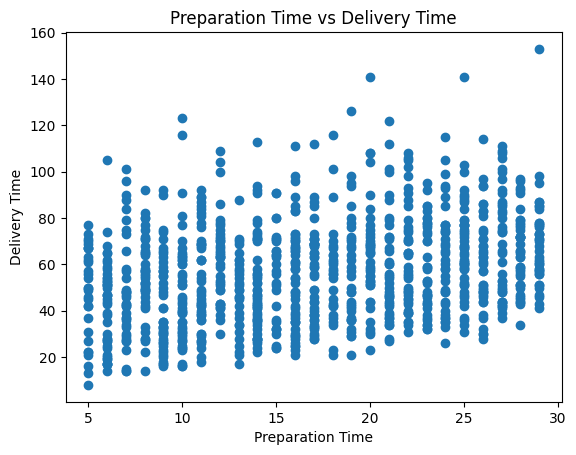

In [16]:
# Preparation vs Delivery Time
plt.scatter(df['preparation_time_min'], df['delivery_time_min'])
plt.title('Preparation Time vs Delivery Time')
plt.xlabel('Preparation Time')
plt.ylabel('Delivery Time')
plt.show()

**Insight**

Terdapat hubungan positif antara waktu persiapan dan waktu pengiriman, di mana semakin lama waktu persiapan makanan, semakin tinggi total delivery time. Namun, hubungan ini tidak terlalu kuat karena masih terdapat variasi delivery time pada setiap tingkat preparation time.

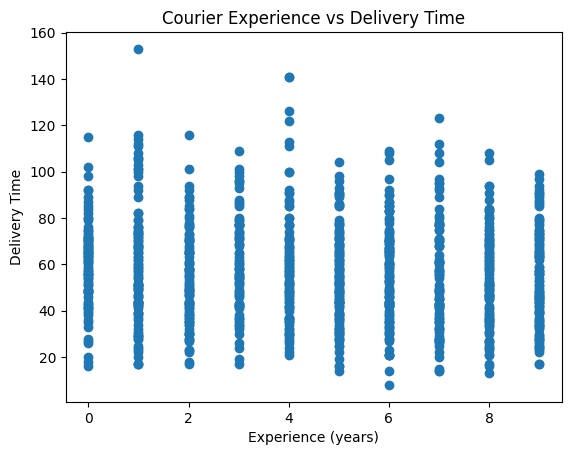

In [17]:
#Experience vs Delivery Time
plt.scatter(df['courier_experience_yrs'], df['delivery_time_min'])
plt.title('Courier Experience vs Delivery Time')
plt.xlabel('Experience (years)')
plt.ylabel('Delivery Time')
plt.show()

**Insight**

Pengalaman kurir tidak menunjukkan hubungan yang kuat terhadap waktu pengiriman. Meskipun secara teori kurir yang lebih berpengalaman seharusnya lebih efisien, pada data ini terlihat bahwa delivery time tetap bervariasi di setiap tingkat pengalaman. Hal ini mengindikasikan bahwa faktor lain seperti jarak, kemacetan, dan cuaca memiliki pengaruh yang lebih dominan dibandingkan pengalaman kurir.

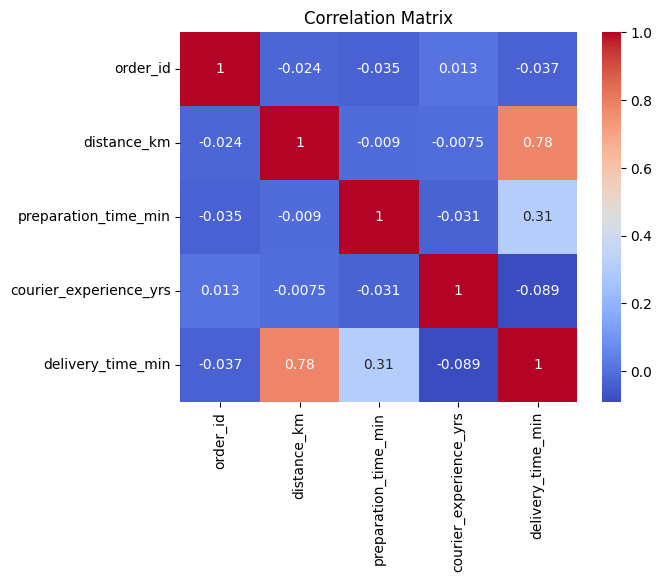

In [18]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Correlation Analysis**

Hasil analisis korelasi menunjukkan bahwa:

- Distance memiliki korelasi positif yang kuat dengan delivery time (0.78), yang mengindikasikan bahwa semakin jauh jarak pengiriman, semakin lama waktu yang dibutuhkan. Ini merupakan faktor paling dominan dalam menentukan waktu pengiriman.

- Preparation time memiliki korelasi positif sedang dengan delivery time (0.31), yang berarti waktu persiapan makanan turut berkontribusi terhadap lamanya pengiriman, meskipun tidak sebesar pengaruh jarak.

- Courier experience memiliki korelasi negatif yang sangat lemah (-0.089) terhadap delivery time, menunjukkan bahwa pengalaman kurir tidak memberikan pengaruh signifikan terhadap kecepatan pengiriman.

- Order ID tidak memiliki korelasi yang berarti dengan variabel lain, sehingga tidak relevan untuk digunakan dalam pemodelan.

Secara keseluruhan, faktor utama yang mempengaruhi delivery time adalah distance dan preparation time, sementara faktor lain seperti pengalaman kurir memiliki dampak yang relatif kecil.

#Feature Engineering

In [19]:
df = df.drop(columns=['order_id'])
# order_id hanya identifier

##Encoding

In [20]:
# OHE
df = pd.get_dummies(df, drop_first=True)

## Split Train-Test

In [21]:
X = df.drop('delivery_time_min', axis=1)
y = df['delivery_time_min']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Scaling


In [23]:
scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

#Modeling

##Linear Regression

In [69]:
# Inisialisasi model
lr = LinearRegression()

# Training
lr.fit(X_train, y_train)

LinearRegression()

In [71]:
y_pred_lr = lr.predict(X_test)

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression Performance:
MAE: 5.899168698353487
RMSE: 8.826470149873378
R2: 0.8261894538886113


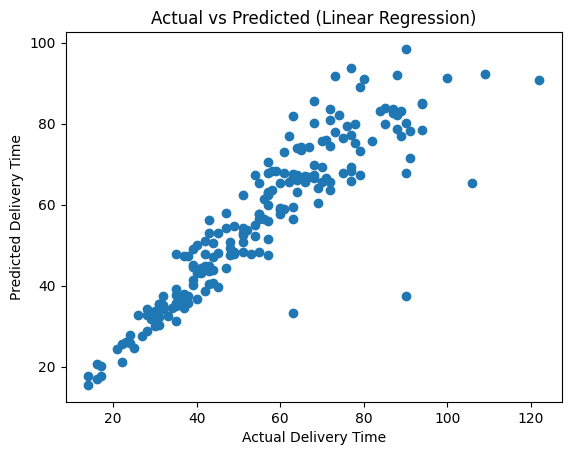

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

In [28]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

coeff_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
5,weather_Snowy,9.246816
3,weather_Foggy,5.816452
4,weather_Rainy,4.639445
0,distance_km,3.001304
6,weather_Windy,1.446947
9,time_of_day_Evening,1.004784
1,preparation_time_min,0.969158
12,vehicle_type_Car,0.517729
10,time_of_day_Morning,-0.169274
2,courier_experience_yrs,-0.677165


##Random Forest

In [29]:
# Inisialisasi
rf = RandomForestRegressor(random_state=42)

# Training
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [30]:
#Predict
y_pred_rf = rf.predict(X_test)

In [31]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Performance:
MAE: 7.1429
RMSE: 10.318234635827972
R2: 0.7624730952437657


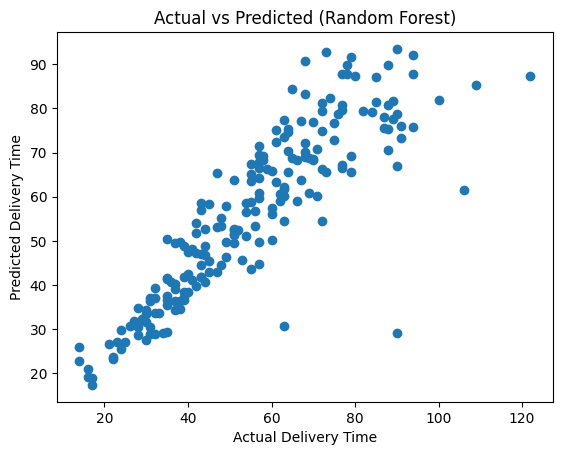

In [32]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [33]:
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

feature_importance_df.sort_values(by='Importance', ascending=False)

,Feature,Importance
0,distance_km,0.698920
1,preparation_time_min,0.158465
2,courier_experience_yrs,0.043391
7,traffic_level_Low,0.019128
9,time_of_day_Evening,0.011834
5,weather_Snowy,0.011235
4,weather_Rainy,0.010454
12,vehicle_type_Car,0.008866
3,weather_Foggy,0.008690
13,vehicle_type_Scooter,0.008036


##XGBoost

In [34]:
from xgboost import XGBRegressor

# Inisialisasi model
xgb = XGBRegressor(random_state=42)

# Training
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [35]:
# Predict
y_pred_xgb = xgb.predict(X_test)

In [36]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance:")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

XGBoost Performance:
MAE: 7.662957668304443
RMSE: 10.68439175207538
R2: 0.7453160285949707


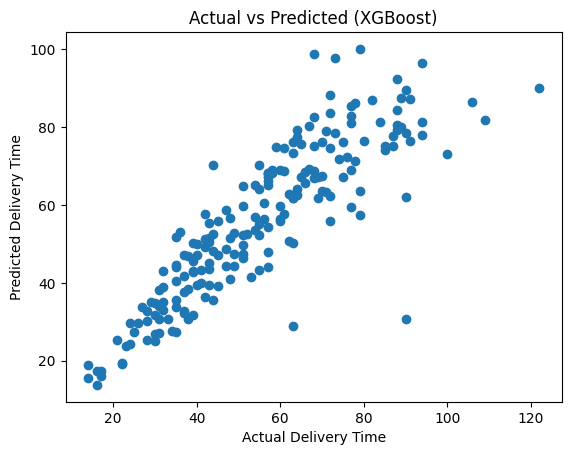

In [37]:
plt.scatter(y_test, y_pred_xgb)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted (XGBoost)")
plt.show()

In [38]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance_df.sort_values(by='Importance', ascending=False)

,Feature,Importance
0,distance_km,0.264254
1,preparation_time_min,0.105535
7,traffic_level_Low,0.093676
5,weather_Snowy,0.083096
3,weather_Foggy,0.072921
4,weather_Rainy,0.055719
13,vehicle_type_Scooter,0.050995
2,courier_experience_yrs,0.049342
12,vehicle_type_Car,0.044095
8,traffic_level_Medium,0.043975


##Tuning Linear Regression

In [39]:
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

In [40]:
ridge = Ridge()

ridge_grid = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_

In [41]:
lasso = Lasso()

lasso_grid = GridSearchCV(lasso, param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_

In [42]:
models_tuned = {
    "Ridge": best_ridge,
    "Lasso": best_lasso
}

results_tuned = []

for name, model in models_tuned.items():
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results_tuned.append([name, mae, rmse, r2])

pd.DataFrame(results_tuned, columns=["Model", "MAE", "RMSE", "R2"])

,Model,MAE,RMSE,R2
0,Ridge,5.910047,8.842969,0.825539
1,Lasso,5.914658,8.844201,0.825490


##Tuning XGBoost

In [43]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

In [44]:
#Param Grid
param_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

In [45]:
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_xgb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [46]:
best_xgb = grid_search_xgb.best_estimator_

print("Best Parameters:", grid_search_xgb.best_params_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [55]:
y_pred_best_xgb = best_xgb.predict(X_test)

mae_xgb_tuned = mean_absolute_error(y_test, y_pred_best_xgb)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_best_xgb))
r2_xgb_tuned = r2_score(y_test, y_pred_best_xgb)

print("Tuned XGBoost Performance:")
print("MAE:", mae_xgb_tuned)
print("RMSE:", rmse_xgb_tuned)
print("R2:", r2_xgb_tuned)

Tuned XGBoost Performance:
MAE: 6.668856620788574
RMSE: 9.55892658160832
R2: 0.796145498752594


##Tuning Random Forest

In [51]:
rf_model = RandomForestRegressor(random_state=42)

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [52]:
# Grid Search
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_rf,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [53]:
best_rf = grid_search_rf.best_estimator_

print("Best Parameters:", grid_search_rf.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [54]:
y_pred_rf_tuned = best_rf.predict(X_test)

mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest Performance:")
print("MAE:", mae_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("R2:", r2_rf_tuned)

Tuned Random Forest Performance:
MAE: 7.046405102466976
RMSE: 10.262797750417995
R2: 0.7650185652793773


Model kompleks tidak selalu lebih baik, pemilihan model harus disesuaikan dengan karakteristik data.

##Model Comparison

In [57]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "Random Forest (Tuned)",
        "XGBoost (Before Tuning)",
        "XGBoost (After Tuning)"
    ],
    "RMSE": [
        8.82,
        8.84,
        8.84,
        10.31,
        10.26,
        10.68,
        9.55
    ]
})

# Urutkan dari terbaik
comparison = comparison.sort_values(by="RMSE")

comparison

,Model,RMSE
0,Linear Regression,8.82
1,Ridge Regression,8.84
2,Lasso Regression,8.84
6,XGBoost (After Tuning),9.55
4,Random Forest (Tuned),10.26
3,Random Forest,10.31
5,XGBoost (Before Tuning),10.68


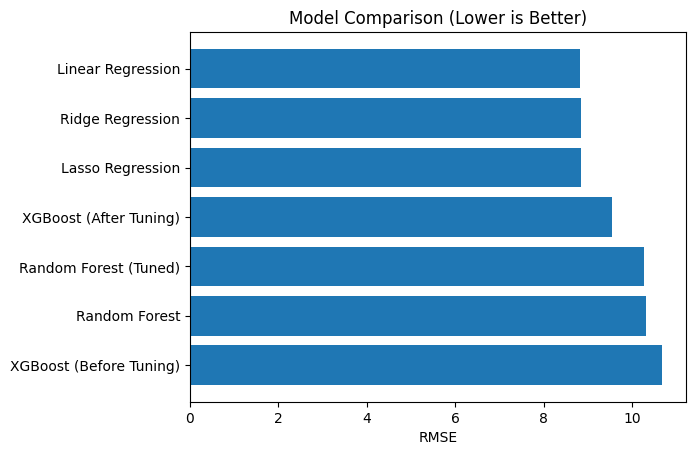

In [58]:
plt.barh(comparison["Model"], comparison["RMSE"])
plt.xlabel("RMSE")
plt.title("Model Comparison (Lower is Better)")
plt.gca().invert_yaxis()
plt.show()

### Insight

Berdasarkan hasil evaluasi menggunakan RMSE, Linear Regression menjadi model dengan performa terbaik dengan nilai RMSE sebesar 8.82, yang menunjukkan tingkat error paling rendah dalam memprediksi waktu pengiriman.

Model Ridge dan Lasso Regression yang merupakan pengembangan dari Linear Regression tidak memberikan peningkatan performa yang signifikan, dengan nilai RMSE yang sedikit lebih tinggi (8.84). Hal ini mengindikasikan bahwa model Linear Regression dasar sudah cukup optimal dan tidak memerlukan regularisasi tambahan.

XGBoost menunjukkan peningkatan performa setelah dilakukan hyperparameter tuning, dari RMSE 10.68 menjadi 9.55. Meskipun demikian, performanya masih berada di bawah Linear Regression, yang menunjukkan bahwa kompleksitas model tidak selalu menghasilkan performa yang lebih baik.

Random Forest juga mengalami sedikit peningkatan setelah tuning, namun tetap memiliki performa yang lebih rendah dibandingkan model lainnya.

Secara keseluruhan, hasil ini menunjukkan bahwa hubungan antara fitur dan target dalam dataset cenderung linear, sehingga model sederhana seperti Linear Regression lebih efektif dibandingkan model berbasis ensemble atau boosting.

#SHAP

In [60]:
import shap

# Konversi kolom boolean di X_train dan X_test ke integer
X_train_numeric = X_train.astype(float)
X_test_numeric = X_test.astype(float)

# Gunakan model XGBoost terbaik (setelah tuning)
explainer = shap.Explainer(best_xgb, X_train_numeric)

shap_values = explainer(X_test_numeric)

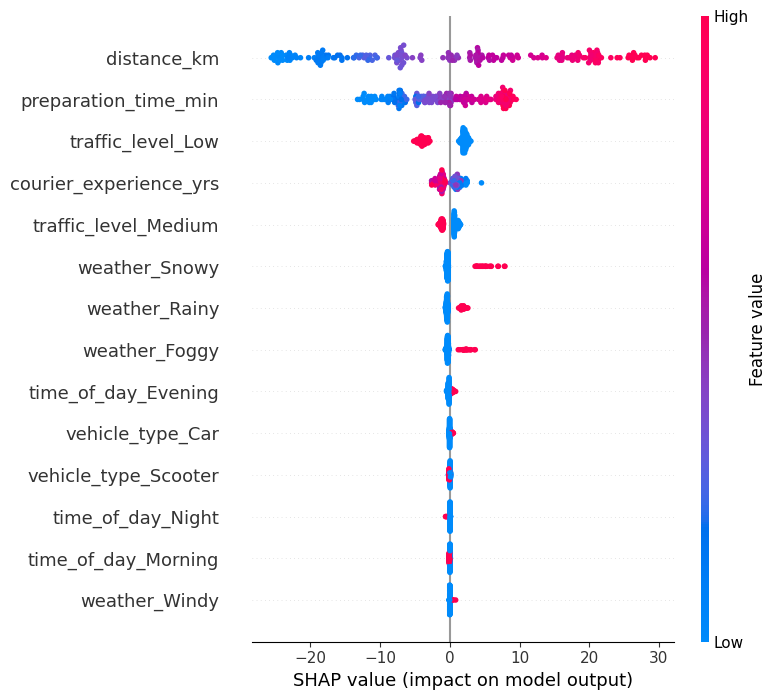

In [61]:
shap.summary_plot(shap_values, X_test)

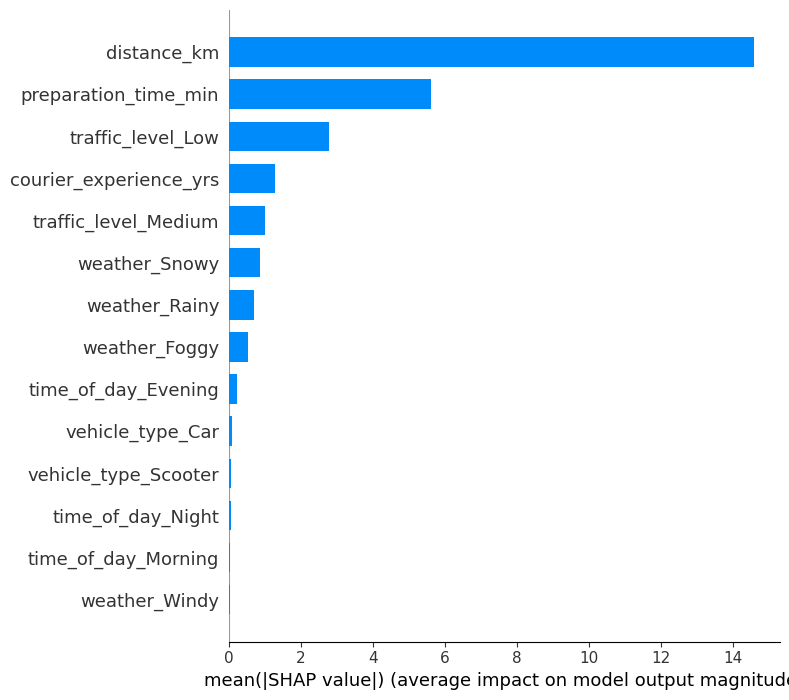

In [62]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

## Feature Importance using SHAP

Berdasarkan analisis SHAP, fitur yang paling berpengaruh terhadap prediksi delivery time adalah distance, diikuti oleh preparation time dan kondisi traffic.

Nilai SHAP menunjukkan bahwa semakin tinggi jarak pengiriman, semakin besar kontribusinya terhadap peningkatan waktu pengiriman. Sementara itu, fitur seperti pengalaman kurir memiliki kontribusi yang relatif kecil terhadap prediksi model.

Hasil ini konsisten dengan analisis sebelumnya, yang menunjukkan bahwa faktor operasional seperti jarak dan kondisi lalu lintas memiliki peran dominan dalam menentukan waktu pengiriman.

#Setup Streamlit

In [73]:
import pickle

with open("model_lr.pkl", "wb") as file:
    pickle.dump(lr, file)

In [74]:
with open("columns.pkl", "wb") as file:
    pickle.dump(X.columns, file)